## Assignment 8 - Deadline: Dec 7, 2025, Sun 11pm

#### DSAI 510 Fall 2025

Complete the assignment below and upload <span style="color:red">both the .ipynb file and its pdf</span> to https://moodle.boun.edu.tr by the deadline given above. The submission page on Moodle will close automatically after this date and time.


To make a pdf, this may work: Hit CMD+P or CTRL+P, and save it as PDF. You may also use other options from the File menu.

In [1]:
# Run this cell first

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Set the display option to show all rows scrolling with a slider
# pd.set_option('display.max_rows', None)
# To disable this, run the line below:
# pd.reset_option('display.max_rows')

## Note: 
In the problems below, if they ask "show the number of records that are nonzero", 
the answer is a number; so you don't need to show the records themselves.
But if it asks, "show the records with NaN", it wants you to print those records (rows)
containing NAN and other entries, not asking how many such records there are. So be careful about what you're asked.

## Problem 1: Age IQ Wealth dataset (40 pts)

Here we'll use PCA to reduce the dimension of the data.

1) Load the age-iq-wealth dataset and apply standardization to the numerical columns. Standardization is needed before applying PCA.
2) Apply PCA by using the function `PCA()` from `sklearn.preprocessing` (no dimensional reduction yet) and call the output `principalComponents`. The `principalComponents` matrix should have the same dimensions as the original matrix (excluding the "Name" column).
3) Round `principalComponents` to 3 decimal places. Any column came out all zeros?
4) Use `explained_variance_ratio_` attribute of the `PCA()` class to calculate the proportion of variance explained by each principal component. The principal coordinates (columns of `principalComponents` matrix) with associated high variance correspond to important ones. The ones with **relatively** low variance can be eliminated. Which unimportant principal coordinate or coordinates would you eliminate based on the three variances you get?
5) Now redo PCA but this time enforce that it produces only two principal components by using `pca = PCA(n_components=2)`, i.e., performing PCA and dimensional reduction in one step.
6) The two principal components are related to the original coordinates (features) through PC1 = a Age + b IQ + c Weight and PC2 = d Age + e IQ + f Weight where a,b,c,d,e and f are called "loadings". Find the loadings by using `components_` attribute of `PCA()` and create a table as below

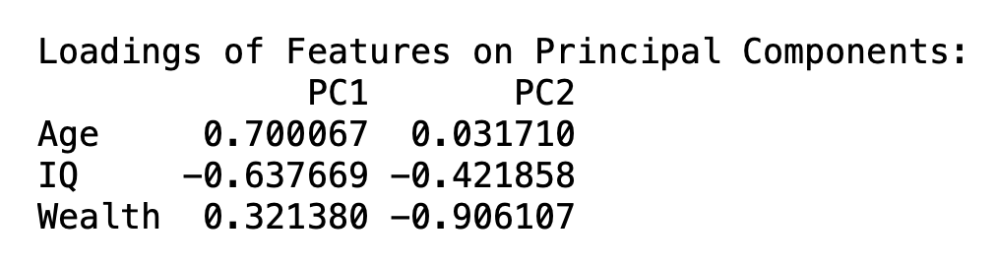

7) Use the loadings calculated in the previous step and show **algebraically** (not using code, just formulas in a markdown cell) that by using Age, IQ and Weight, you can find the PC1 value for ther record "Ali". Show your calculation. (Ali, or any record, is at the same row both in the original data matrix and the PCA transformed one.) 
8) Make a 2D scatterplot of the data, found via `pca = PCA(n_components=2)`, with coordinates PC1 and PC2. Do you see any clusters in the reduced 2D space? If yes, how many clusters do you see?


In [2]:
df = pd.read_csv('./age-iq-wealth.csv')

df.head()

,Name,Age,IQ,Wealth
0,Xiaoping,67,66,533
1,Yun,69,60,525
2,Florence,75,70,585
3,Norma,57,67,486
4,Mohamad,55,63,464


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numerical_cols = ['Age', 'IQ', 'Wealth']
scaler = StandardScaler()
df_std = df.copy()
df_std[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [4]:
pca = PCA()
principalComponents = pca.fit_transform(df_std[numerical_cols])
principalComponents

array([[ 1.39754311e+00, -1.79602094e-01, -1.93290513e-16],
       [ 1.53900018e+00, -4.78169027e-01, -1.11617714e-16],
       [ 2.07964291e+00,  1.19303372e+00, -1.64620786e-16],
       [ 5.69833674e-01, -1.34534610e+00, -7.29123740e-17],
       [ 3.86851063e-01, -1.96353043e+00, -1.74678560e-16],
       [ 1.80516899e+00,  2.65757219e-01, -1.45161534e-16],
       [ 2.15867656e+00,  1.22710050e+00, -2.09381775e-16],
       [ 1.37262779e+00, -7.29652853e-01, -1.72200597e-16],
       [ 4.82494922e-01, -1.56276314e+00, -1.32638260e-16],
       [ 6.44714766e-01, -1.40295444e+00, -1.92097297e-16],
       [ 5.82291335e-01, -1.07032072e+00, -1.24408788e-16],
       [ 1.65955936e+00,  4.72649025e-01, -2.48701388e-16],
       [ 2.37086217e+00,  7.79250104e-01, -2.90607986e-16],
       [ 1.48488186e+00,  3.78149460e-02, -2.76523814e-16],
       [ 1.32266202e+00, -1.21993753e-01, -2.28155026e-16],
       [ 7.32053518e-01, -1.18553740e+00, -1.10190914e-16],
       [ 9.56696793e-01, -1.35836242e+00

In [5]:
principalComponents_rounded = np.round(principalComponents, 3)
print("Principal Components:")
print(principalComponents_rounded)
print("Column sums:")
print(np.sum(np.abs(principalComponents_rounded), axis=0))
# Wealth column came out all zeros.

Principal Components:
[[ 1.398 -0.18  -0.   ]
 [ 1.539 -0.478 -0.   ]
 [ 2.08   1.193 -0.   ]
 [ 0.57  -1.345 -0.   ]
 [ 0.387 -1.964 -0.   ]
 [ 1.805  0.266 -0.   ]
 [ 2.159  1.227 -0.   ]
 [ 1.373 -0.73  -0.   ]
 [ 0.482 -1.563 -0.   ]
 [ 0.645 -1.403 -0.   ]
 [ 0.582 -1.07  -0.   ]
 [ 1.66   0.473 -0.   ]
 [ 2.371  0.779 -0.   ]
 [ 1.485  0.038 -0.   ]
 [ 1.323 -0.122 -0.   ]
 [ 0.732 -1.186 -0.   ]
 [ 0.957 -1.358 -0.   ]
 [ 1.805  0.266 -0.   ]
 [ 1.223 -0.614 -0.   ]
 [ 2.08   1.193 -0.   ]
 [ 1.876  0.116 -0.   ]
 [ 0.653 -1.22  -0.   ]
 [ 0.553 -1.712 -0.   ]
 [ 1.739  0.507 -0.   ]
 [ 1.576  0.347 -0.   ]
 [-1.331 -0.547  0.   ]
 [-1.024  1.114  0.   ]
 [-1.036  0.839  0.   ]
 [-0.969  0.598  0.   ]
 [-2.305 -1.506  0.   ]
 [-0.924  1.606  0.   ]
 [-0.774  1.491  0.   ]
 [-1.048  0.564  0.   ]
 [-2.138 -1.254  0.   ]
 [-2.192 -0.738  0.   ]
 [-1.976 -1.094  0.   ]
 [-1.868 -0.419  0.   ]
 [-1.252  1.195  0.   ]
 [-0.874  0.999  0.   ]
 [-1.934 -0.178  0.   ]
 [-1.152 -0.02   0

In [6]:
print("Explained Variance")
print(pca.explained_variance_ratio_) # PC3 should be eliminated
print(f"Cumulative variance: {np.cumsum(pca.explained_variance_ratio_)}")

Explained Variance
[0.67948506 0.32051494 0.        ]
Cumulative variance: [0.67948506 1.         1.        ]


In [7]:
pca_2d = PCA(n_components=2)
principalComponents_2d = pca_2d.fit_transform(df_std[numerical_cols])

loadings_df = pd.DataFrame(
    pca_2d.components_.T,
    index=['Age', 'IQ', 'Wealth'],
    columns=['PC1', 'PC2']
)
print("Loadings Table:")
print(loadings_df)

Loadings Table:
             PC1       PC2
Age     0.700067 -0.031710
IQ     -0.637669  0.421858
Wealth  0.321380  0.906107


In [8]:
ali_standardized = df_std[df_std['Name'] == 'Ali'][numerical_cols].values[0]
print(f"Ali's standardized values:")
print(f"Age: {ali_standardized[0]:.6f}")
print(f"IQ: {ali_standardized[1]:.6f}")
print(f"Wealth: {ali_standardized[2]:.6f}")

Ali's standardized values:
Age: 0.387335
IQ: -0.966936
Wealth: -1.260966


$PC1_{Ali}=(0.700×0.387)+(−0.638×−0.967)+(0.321×−1.261)=0.482$

Ali's PC1: 0.482495


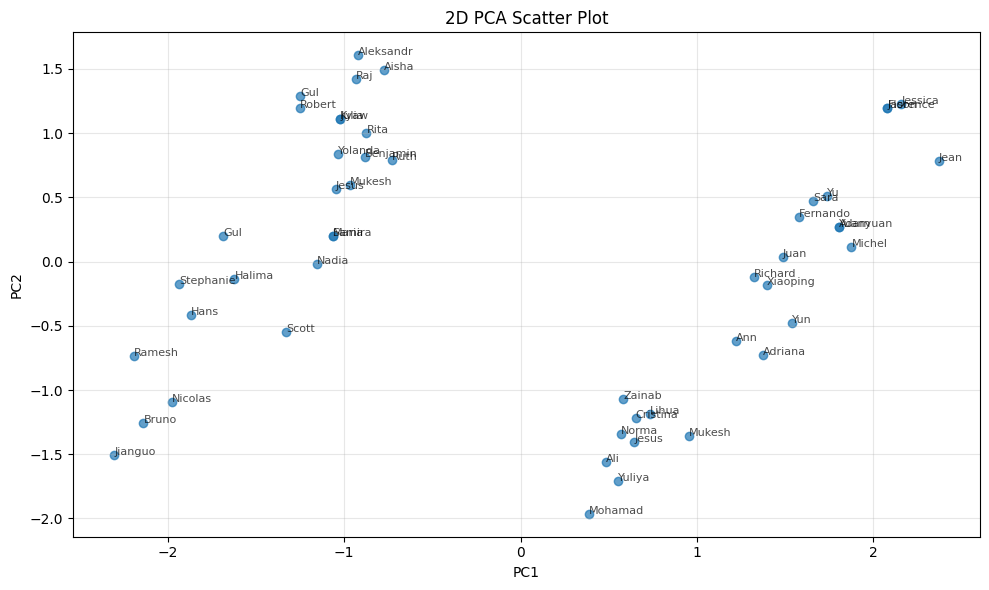

In [9]:
ali_pc1_actual = principalComponents_2d[df['Name'] == 'Ali', 0][0]
print(f"Ali's PC1: {ali_pc1_actual:.6f}")

plt.figure(figsize=(10, 6))
plt.scatter(principalComponents_2d[:, 0], principalComponents_2d[:, 1], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA Scatter Plot')
plt.grid(True, alpha=0.3)
for i, name in enumerate(df['Name']):
    plt.annotate(name, (principalComponents_2d[i, 0], principalComponents_2d[i, 1]), 
                 fontsize=8, alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
# It can be seen that there's a two clearly distinct clusters on the left and right.

## Problem 2: Clustering disk & circle dataset (30 pts)

We've used neural networks in the class to cluster the disk and circle dataset given below. 

1) Now use another algorithm of your choice that would cluster the outer circle and inner disk correctly. Do not use neural networks; you're free to use any other clustering algorithm, including the ones we did not mention in class. 

2) Generate scatter plot by using a different color for each cluster (the inner disk and outer circle). Your plot should look like the plot on the right, marked as correct. If you can't get the clustering _mostly_ right, play with the hyperparameters of your clustering algorithm or choose another algorithm. (The data points are shown in a scatter plot output in the code blocks below. It is okay if the data points between the inner disk and outer circle are not clustered as you expected. As long as you cluster the disk and the circle as different clusters, your output is acceptable.)

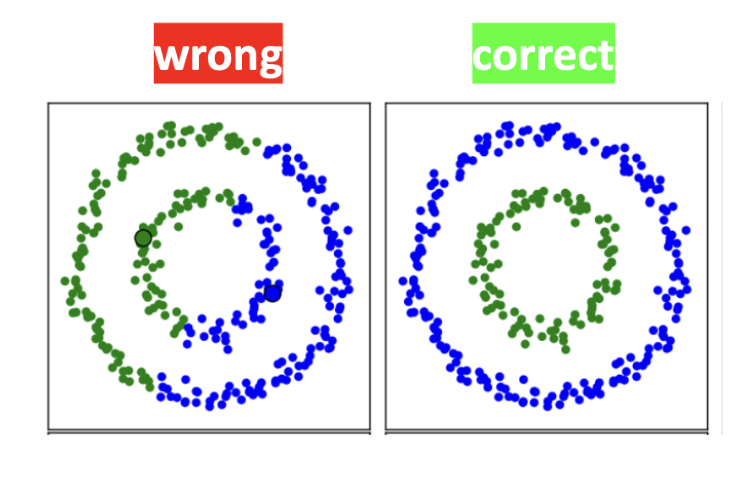

In [11]:
dfcirc = pd.read_csv('./disk-and-circle.csv')
dfcirc.head()

,feature1,feature2
0,-9.049800,-3.762775
1,1.882356,-0.032469
2,-5.818836,6.980322
3,-1.844639,4.959437
4,6.903243,-6.721458


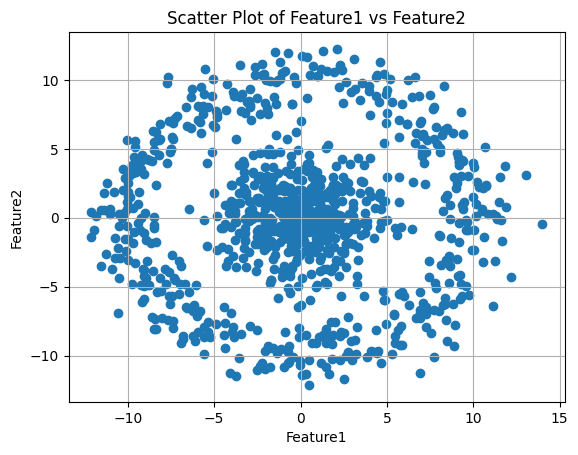

In [12]:
plt.scatter(dfcirc['feature1'], dfcirc['feature2'])

# Adding labels and title
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.title('Scatter Plot of Feature1 vs Feature2')

# Showing the plot
plt.grid(True)
plt.show()

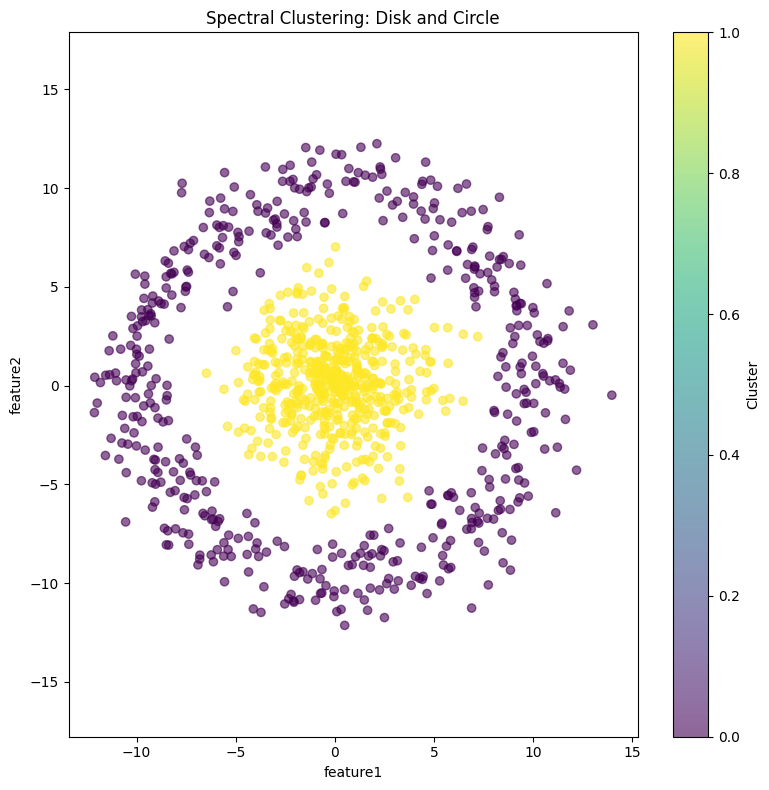

In [13]:
from sklearn.cluster import SpectralClustering
X = dfcirc[['feature1', 'feature2']].values

spectral = SpectralClustering(n_clusters=2, affinity='rbf', n_neighbors=4, random_state=42)
clusters = spectral.fit_predict(X)

plt.figure(figsize=(8, 8))
scatter = plt.scatter(dfcirc['feature1'], dfcirc['feature2'], c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.title('Spectral Clustering: Disk and Circle')
plt.colorbar(scatter, label='Cluster')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Problem 3: Clustering on data from Kaggle (30 pts)

Go to [kaggle.com](kaggle.com). 

(a) Find a dataset that is related to your professional field or the field you're interested in by using the search bar at the very top of the page. Add the link of the data to this notebook.

(b) Use a clustering algorithm of your choice to cluster that data. Generate scatter plot by coloring each cluster in a different color. (Do not copy the code on Kaggle exactly, modify it, make it yours.)

In [14]:
# https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset
# Factors that can impact GPA have always been an interesting topic to check for me.

import pandas as pd 

student = pd.read_csv('Student_performance_data _.csv')
student

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


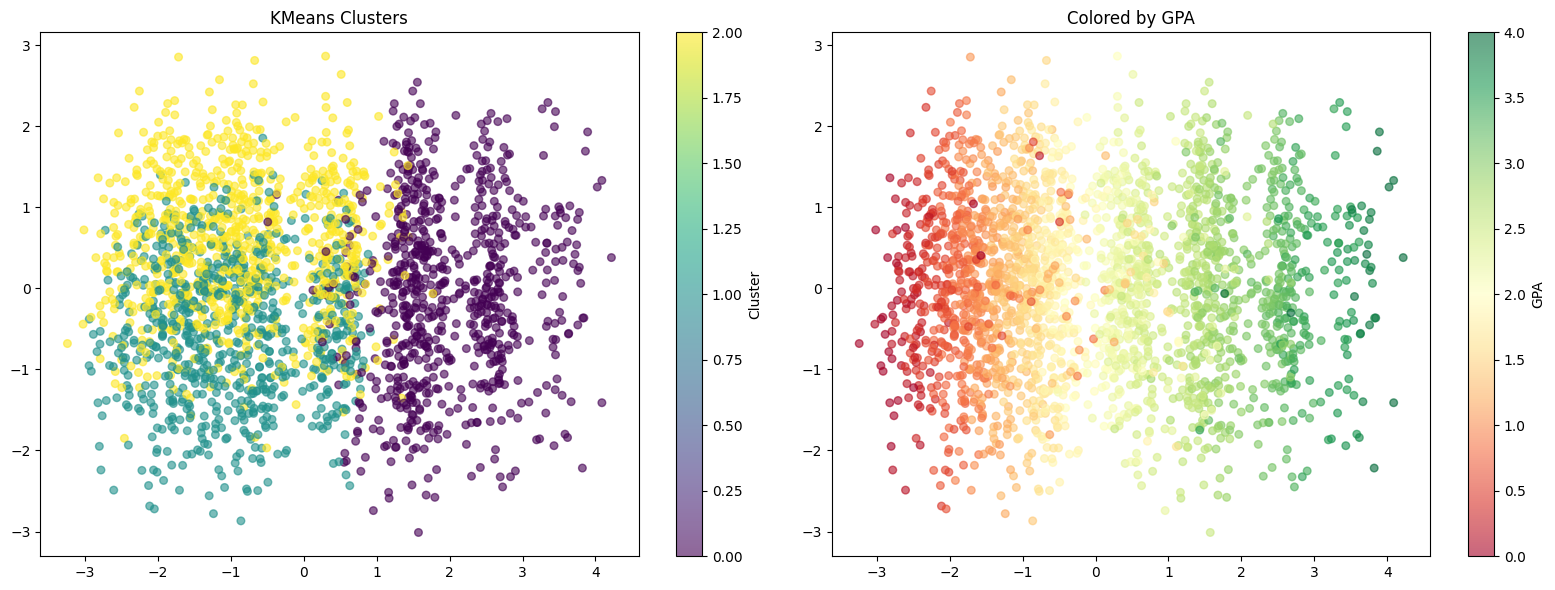

Explained variance: [0.29880989 0.12008418]
Total variance: 41.89%


GPA      StudyTimeWeekly        Absences        Hobbies       \
             mean size            mean size       mean size      mean size   
Cluster                                                                      
0        2.923624  759       10.721683  759   5.317523  759  1.451910  759   
1        1.393987  747        9.342790  747  19.183400  747  1.302544  747   
2        1.467269  884        9.301532  884  18.516968  884  1.279412  884   

        Ethnicity      ParentalSupport       
             mean size            mean size  
Cluster                                      
0        0.901186  759        2.239789  759  
1        0.838019  747        2.056225  747  
2        0.892534  884        2.079186  884

In [15]:
from sklearn.cluster import KMeans, SpectralClustering

student = pd.read_csv('Student_performance_data _.csv')
student = student[~student['StudentID'].isin([3300, 3376])]

data = student.drop(['StudentID', 'Ethnicity'], axis=1).copy()
data['Hobbies'] = data['Extracurricular'] + data['Sports'] + data['Music'] + data['Volunteering'] + data['Tutoring']
data = data.drop(['Extracurricular', 'Sports', 'Music', 'Volunteering', 'Tutoring'], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
# clusters = kmeans.fit_predict(X_scaled)

spectral = SpectralClustering(n_clusters=3, affinity='rbf', n_neighbors=10, random_state=42)
clusters = spectral.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=30)
axes[0].set_title('KMeans Clusters')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=student['GPA'], cmap='RdYlGn', alpha=0.6, s=30)
axes[1].set_title('Colored by GPA')
plt.colorbar(scatter2, ax=axes[1], label='GPA')

plt.tight_layout()
plt.show()

print(f"Explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance: {pca.explained_variance_ratio_.sum():.2%}")

student['Cluster'] = clusters
student['Hobbies'] = data['Hobbies'].values
student.groupby('Cluster')[['GPA', 'StudyTimeWeekly', 'Absences', 'Hobbies', 'Ethnicity', 'ParentalSupport']].agg(['mean', 'size'])

In [16]:
# From high GPA cluster we can see that top GPA students study more weekly, go to classes more frequently, do more number of hobbies, and receives more parental support.

## For fun

In [17]:
# https://www.kaggle.com/datasets/sheikhsohelmoon/harry-potters-second-wizard-war-dataset

In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

df = pd.read_csv('Second Wizard War DeadorAliveUpdated.csv').drop(['BOGGART', 'HAIR COLOR', 'PATRONUS'], axis=1)

14 [-0.94315944 -0.42768305]
17 [3.72332664e-02 8.25316424e-05]


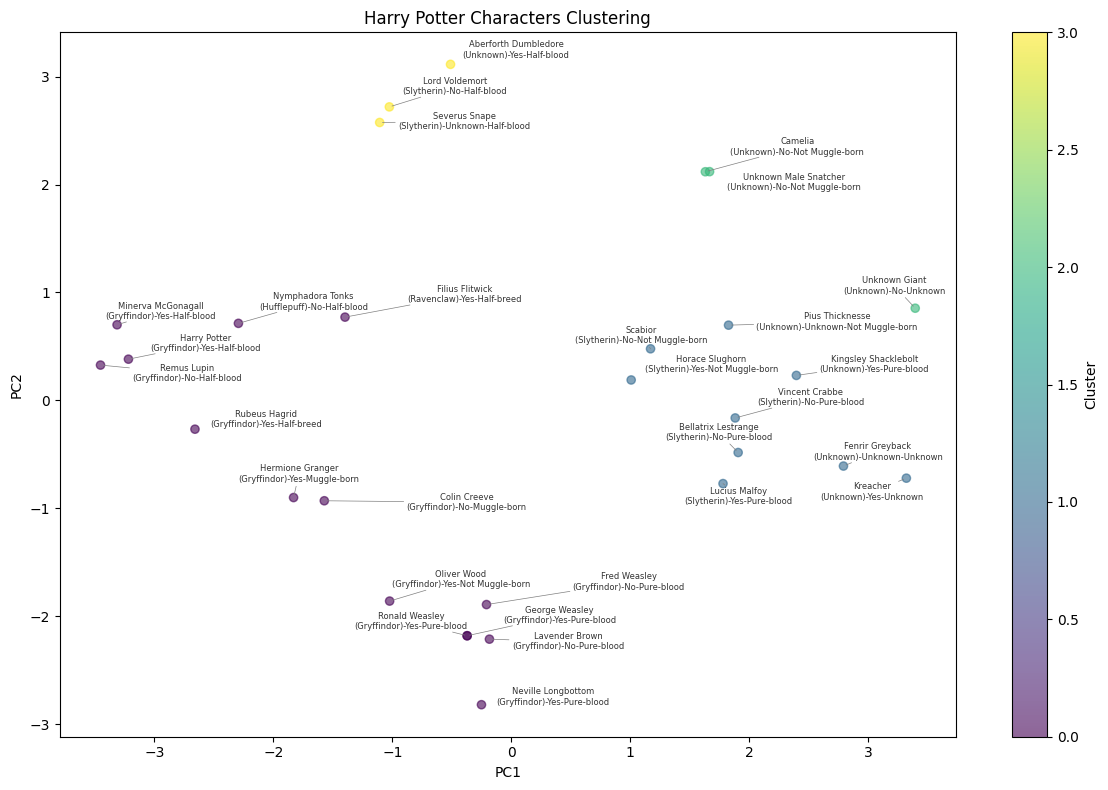

Explained variance: [0.4175901  0.25042494]


In [19]:
from adjustText import adjust_text

categorical_cols = ['BLOOD STATUS', 'Species', 'GENDER', 'HOUSE', 'ALIVE?', 'Nationality']
df_encoded = df[categorical_cols].copy()
for col in categorical_cols:
    df_encoded[col] = df_encoded[col].fillna('Unknown')
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

spectral = SpectralClustering(n_clusters=4, affinity='rbf', n_neighbors=4, random_state=42)
clusters = spectral.fit_predict(df_encoded)

# kmeans = KMeans(n_clusters=4, random_state=42)
# clusters = kmeans.fit_predict(df_encoded)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_encoded)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Harry Potter Characters Clustering')
plt.colorbar(scatter, label='Cluster')

texts = []
for i in range(len(df)):
    house = df['HOUSE'].iloc[i] if pd.notna(df['HOUSE'].iloc[i]) else 'Unknown'
    alive = df['ALIVE?'].iloc[i] if pd.notna(df['ALIVE?'].iloc[i]) else 'Unknown'
    blood_status = df['BLOOD STATUS'].iloc[i] if pd.notna(df['BLOOD STATUS'].iloc[i]) else 'Unknown'
    label = f"{df['NAME'].iloc[i]}\n({house})-{alive}-{blood_status}"
    texts.append(plt.text(X_pca[i, 0], X_pca[i, 1], label, fontsize=6, alpha=0.8))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
plt.tight_layout()
plt.show()

print(f"Explained variance: {pca.explained_variance_ratio_}")

In [21]:
from scipy import stats

data = [2, 2, 1, 2, 3]

# For standard deviation
stats.tstd(data)  # sample std (n-1 denominator)

# Or use numpy which is more common
import numpy as np
np.std(data, ddof=1)  # ddof=1 for sample std

np.float64(0.7071067811865476)